字母级别的预测(预测单个字母)[已被淘汰]

In [1]:
# 读取shakespeare.txt，构建字符级字典
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

# 构建字符到索引的映射字典
# set去重,排序, 转换为列表,每个字符对应一个索引
chars = sorted(list(set(text)))
#enumerate: 为每个字符分配一个唯一的索引, 从0开始
#（字符→索引）
char2idx = {ch: idx for idx, ch in enumerate(chars)}# 字符到索引的映射字典
#（索引→字符）
idx2char = {idx: ch for idx, ch in enumerate(chars)}# 索引到字符的映射字典

print(f"字符到索引的映射字典: {char2idx}")
print('-'*100)
print(f"索引到字符的映射字典: {idx2char}")
print(char2idx['!'])


字符到索引的映射字典: {'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
----------------------------------------------------------------------------------------------------
索引到字符的映射字典: {0: '\n', 1: ' ', 2: '!', 3: '$', 4: '&', 5: "'", 6: ',', 7: '-', 8: '.', 9: '3', 10: ':', 11: ';', 12: '?', 13: 'A', 14: 'B', 15: 'C', 16: 'D', 17: 'E', 18: 'F', 19: 'G', 20: 'H', 21: 'I', 22: 'J', 23: 'K', 24: 'L', 25: 'M', 26: 'N', 27: 'O', 28: 'P', 29: 'Q', 30: 'R', 31: 'S', 32: 'T', 33: 'U', 

In [2]:
# 将文本转换为索引序列
# text_ids=[char2idx[ch] for ch in text]
text_ids = []
for ch in text:
    text_ids.append(char2idx[ch])
    
text_ids[0:20]

[18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]

In [3]:
print("文本长度:",len(text_ids))

文本长度: 1115394


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader


# 自定义字符级数据集，用于按固定长度切分文本
class CharDataset(Dataset):
    def __init__(self, text_ids, seq_len=101):
        self.text_ids = text_ids  # 已编码的字符 id 列表
        self.seq_len = seq_len  # 每条样本的字符长度
        self.num_seq = len(text_ids) // seq_len  # 样本个数

    def __len__(self):
        return self.num_seq

    def __getitem__(self, idx):
        # 进行切片，每个样本101个字符
        return self.text_ids[idx * self.seq_len : (idx + 1) * self.seq_len]


# 创建数据集实例，假设 text_ids 已在别处定义
dataset = CharDataset(text_ids, seq_len=101)


def collate_fn(batch):
    """
    将每个样本的101个字符拆成：
    输入：前100个字符
    标签：后100个字符（每个位置对应下一个字符的预测目标）
    """
    batch = torch.tensor(batch, dtype=torch.long)
    x = batch[:, :100]  # 前100个字符作为输入
    y = batch[:, 1:101]  # 后100个字符作为标签/lable
    return x, y


# 构建 DataLoader，用于训练时按批次读取数据
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)

In [5]:
for x,y in dataloader:# 遍历 dataloader，每次取出一个 batch 的数据
    print(x.shape, y.shape)
    break

torch.Size([64, 100]) torch.Size([64, 100])


# 搭建模型

In [6]:
# !pip install tqdm

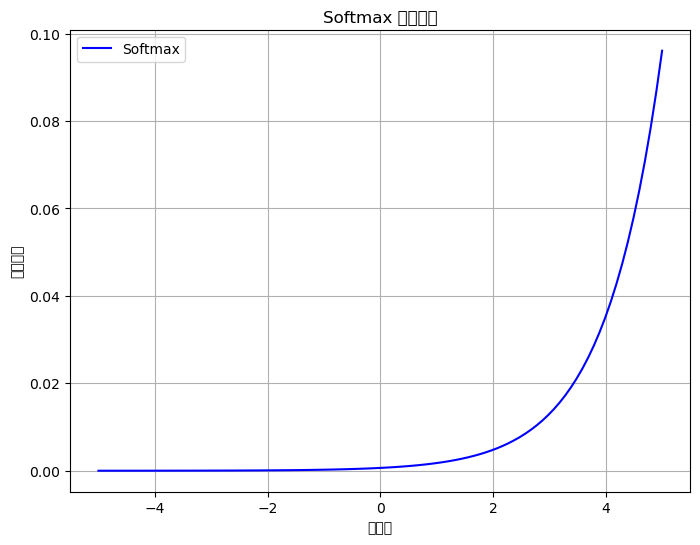

Temperature = 0.01, Softmax Output = [1.00000000e+00 3.72007598e-44 3.04823495e-83]
Temperature = 1.0, Softmax Output = [0.65900114 0.24243297 0.09856589]
Temperature = 10.0, Softmax Output = [0.36605947 0.33122431 0.30271622]


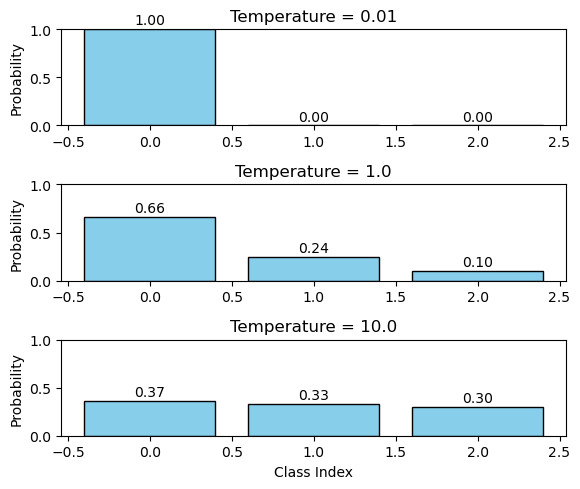

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 原始输入值（logits），可以任意指定
logits = np.array([2.0, 1.0, 0.1])

# 定义不同的 temperature 值，用于观察 softmax 输出的变化
# temperature 越大，输出分布越“平滑”；越小则越“尖锐”
temperatures = [0.01, 1.0, 10.0]

# 创建子图，每行一个 temperature，共 3 行
fig, axes = plt.subplots(len(temperatures), 1, figsize=(6, 5))

# 遍历每个 temperature，计算 softmax 并绘图
for idx, T in enumerate(temperatures):
    # 计算经过 temperature 缩放后的 softmax
    exp = np.exp(logits / T)
    probs = exp / np.sum(exp)
    print(f"Temperature = {T}, Softmax Output = {probs}")
    # 在对应子图上绘制柱状图
    axes[idx].bar(range(len(probs)), probs, color='skyblue', edgecolor='black')
    axes[idx].set_title(f"Temperature = {T}")
    axes[idx].set_ylabel("Probability")
    axes[idx].set_ylim(0, 1)
    # 在柱子上方标注具体概率值
    for i, p in enumerate(probs):
        axes[idx].text(i, p + 0.02, f"{p:.2f}", ha='center', va='bottom')

# 共享 x 轴标签
axes[-1].set_xlabel("Class Index")

plt.tight_layout()
plt.show()


In [7]:
import torch

'''创建一个概率分布,表示每个类别被选中的概率, 这里我们有一个简单的四个类别的概率分布'''
prob_dist=torch.tensor([0.1,0.45,0.35,0.1])

#抽取样本,抽取概率大的样本
sample=torch.multinomial(prob_dist,num_samples=1, replacement=True)

print("概率分布",prob_dist)
print("抽取的样本索引",sample)


概率分布 tensor([0.1000, 0.4500, 0.3500, 0.1000])
抽取的样本索引 tensor([3])


In [8]:

# 生成模型：Embedding + RNN + Linear
class CharRNNGen(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim=128, rnn_hidden=256, num_layers=2):
        super().__init__()
        self.embed = torch.nn.Embedding(vocab_size, embed_dim)      # 字符嵌入层
        self.rnn = torch.nn.RNN(embed_dim, rnn_hidden, num_layers,
                                batch_first=True, nonlinearity='tanh')  # RNN 层
        self.fc = torch.nn.Linear(rnn_hidden, vocab_size)           # 输出映射到字符类别

    def forward(self, x, h=None):
        # x: [B, T]  输入字符序列
        x = self.embed(x)                  # [B, T] -> [B, T, E]
        out, h = self.rnn(x, h)              # [B, T, H], [L, B, H]
        logits = self.fc(out)                # [B, T, V]
        return logits, h                     # 返回 logits 与隐藏状态


# 假设词汇表大小已知（示例值） ，实际使用时替换为真实 vocab_size
vocab_size = len(char2idx)   # 字符到索引的映射长度，即词汇表大小
print(f"词汇表大小: {vocab_size}")
model = CharRNNGen(vocab_size)


词汇表大小: 65


In [9]:
# 从数据加载器取一批数据
x, y = next(iter(dataloader))

# 简单前向计算
output, hidden = model(x)
# 打印模型前向计算的输出张量形状，通常表示每个时间步的预测结果
print("output shape:", output.shape)
# 打印隐藏状态张量形状，通常包含RNN/LSTM等网络在最后一个时间步的隐层输出
print("hidden shape:", hidden.shape)


output shape: torch.Size([64, 100, 65])
hidden shape: torch.Size([2, 64, 256])


 解释张量维度含义  
 output shape: torch.Size([64, 100, 65])  
   64  -> 批次大小（batch size）  
   100 -> 序列长度（sequence length）  
   65  -> 词汇表大小（vocab size），即每个时间步输出的 logits 维度  
  
 hidden shape: torch.Size([2, 64, 256])  
   2   -> LSTM 层数（num_layers）  
   64  -> 批次大小（batch size）  
   256 -> 隐藏层维度（hidden_size）  
  
 综上：  
   output 是给定输入序列后，模型在每个时间步对所有词汇的打分；  
   hidden 是 LSTM 在最后时间步输出的隐状态，供下一步解码或继续生成使用。


# 训练及绘制训练集损失曲线

Epoch 1/10, Loss: 2.2604
Epoch 2/10, Loss: 1.7816
Epoch 3/10, Loss: 1.6387
Epoch 4/10, Loss: 1.5603
Epoch 5/10, Loss: 1.5114
Epoch 6/10, Loss: 1.4762
Epoch 7/10, Loss: 1.4493
Epoch 8/10, Loss: 1.4284
Epoch 9/10, Loss: 1.4114
Epoch 10/10, Loss: 1.3964


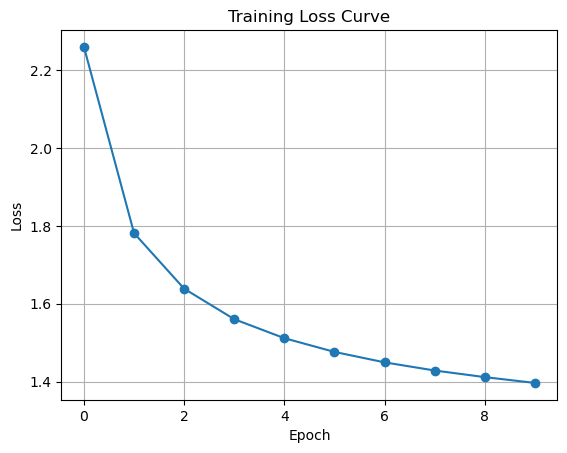

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 选择设备：如果有GPU，优先使用GPU；否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CharRNNGen(vocab_size)  # 初始化字符级RNN模型
model = model.to(device)  # 将模型移动到选定设备上

# 定义损失函数：交叉熵损失，用于分类任务
criterion = nn.CrossEntropyLoss()
# 定义优化器：Adam，学习率为0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练循环：共训练10个epoch
num_epochs = 10
train_losses = []  # 用于记录每个epoch的平均损失，便于后续绘图

for epoch in range(num_epochs):
    model.train()  # 将模型设置为训练模式（启用Dropout、BatchNorm等）
    epoch_loss = 0.0  # 累计当前epoch的总损失
    count = 0  # 记录当前epoch已处理的batch数量（可选）
    for batch_x, batch_y in dataloader:
        # 将输入与标签迁移到指定设备（如GPU）
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()  # 清空过往梯度
        output, _ = model(batch_x)  # 前向传播，获取模型输出
        # 假设output形状为 (batch, seq_len, vocab_size)，需要reshape成二维以适配CrossEntropyLoss
        loss = criterion(
            output.reshape(-1, output.size(-1)), batch_y.reshape(-1)
        )  # 计算交叉熵损失
        loss.backward()  # 反向传播，计算梯度
        optimizer.step()  # 根据梯度更新模型参数

        epoch_loss += loss.item()  # 累计当前batch的损失
        count += 1  # 更新batch计数（可选）

    # 计算当前epoch的平均损失
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)  # 将当前epoch的平均损失添加到列表中
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# 绘制损失曲线：展示训练过程中损失的变化趋势
# plt.figure(figsize=(6, 4))  # 可选：设置图像大小
# plt.plot(range(1, num_epochs+1), train_losses, marker='o')  # 另一种横坐标写法
plt.plot(train_losses, marker="o")  # 以epoch索引为横坐标
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [11]:
from tqdm import tqdm # 显示进度条(但存在兼容性问题)
import torch.nn.functional as F


def generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True):
    """
        使用训练好的模型生成文本
        :param model: 训练好的模型
        :param start_string: 初始文本（种子）
        :param max_len: 生成的最大长度
        :param temperature: 温度系数，控制随机性。值越小越保守，值越大越随机
        :param stream: 是否流式输出打印
        :return: 生成的完整文本
    """

    # 将起始字符串中的每个字符映射为对应的索引，若字符不在词汇表中则默认索引为0
    input_ids = [char2idx.get(c, 0) for c in start_string]
    # 将索引列表转换为PyTorch张量，并增加batch维度后移至指定设备（如GPU）
    input_tensor = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)  # [1, len]

    # 初始化隐藏状态为None，模型将在首次调用时创建初始隐藏状态
    hidden = None
    # 用于存储生成字符的索引列表
    text_generated = []

    # 将模型切换到评估模式，关闭Dropout等训练相关层
    model.eval()
    
    # 若启用流式输出，则先打印起始字符串
    if stream:
        print(start_string, end="", flush=True)

    # 禁用梯度计算，加速推理并节省内存
    with torch.no_grad():
        # 预热阶段：将起始字符串整体输入模型，获取最后一个时间步的输出和隐藏状态
        output, hidden = model(input_tensor, hidden)
        # 提取最后一个时间步的logits，用于后续生成
        last_logits = output[:, -1, :]  # [1, vocab_size]
        
        # 根据是否流式输出决定迭代器：非流式时使用tqdm显示进度条
        iterator = range(max_len)
        if not stream:
             iterator = tqdm(iterator, desc="Generating")
             
        # 循环生成指定数量的字符
        for i in iterator:
            # 温度采样：对logits除以温度，温度越高分布越平滑，随机性越强
            logits = last_logits / temperature  # [1, vocab_size]
            # 计算softmax概率分布，得到每个字符的预测概率
            probs = F.softmax(logits, dim=-1)

            # 从多项分布中采样一个字符索引作为下一个生成的字符
            next_char_idx = torch.multinomial(probs, 1).item()
            # 将生成的字符索引加入列表
            text_generated.append(next_char_idx)
            
            # 若启用流式输出，则立即打印生成的字符
            if stream:
                print(idx2char[next_char_idx], end="", flush=True)
            
            # 构造下一个时间步的输入张量，仅包含最新生成的字符
            input_tensor = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)
            
            # 将新输入传入模型，更新隐藏状态并获取新的logits
            output, hidden = model(input_tensor, hidden)
            # 更新last_logits为当前时间步的输出，用于下一次生成
            last_logits = output[:, -1, :]
            
    # 若启用流式输出，打印换行符表示生成结束
    if stream:
        print()
        
    # 将起始字符串与生成的字符索引序列转换为字符并拼接，返回完整文本
    return start_string + "".join([idx2char[idx] for idx in text_generated])


# 测试生成：以"love"为种子生成1000个字符，温度1.0，启用流式输出
start_string = "love"
res = generate_text(model, start_string, max_len=1000, temperature=1.0, stream=True)

loved it in our tohn humble body: death her too,
Though thou yet this virtuciage. Romeo silence that read good to her:
Now so, if you will know wither.

TRARIEL:
Ay, awe dead for the counted grace look Matter's reputy.

SICINIUS:
I am gone.

HORTENSIO:
Sir; chandel'd not.

KING RICHARD II:
Stay:
Bear the party and actio?

SICINIUS:
Field so hand! about you sun.

LEONTES:
Fit you do sorrow! sever by the senally
Be stand a lessel pale:
Jeen say to-day the breath
The people.
Stand lived, for you do person that have begin?
Who was hadst 'em
seen't.

JULIET:
Unlipulal, by
Then I cursad,
And pad thy tropers,
Of his naughters: stay a gentlemen;' tails:
'Tis as grieves sleep.

BRUTUS:
I have as it false, sir at hupposed and had I see it pasily heir owen.

CAPULET:
The spring in mine.

MENENIUS:
I must pardone's suns,
And Bainou wheter, by fiend? I'll a bake.

CLAUDIO:
Ulen for him call at how they can my soul, I sea with bled I could a feathers ay; and
the open to your
prison, I'll dispatuhe o